## I. Small dataset creation

In [15]:
a = np.random.randint(-10, 10, (4, 3))
b = np.random.randint(-10, 10, (4, 3))

np.stack([a, b], axis=2).shape

(4, 3, 2)

In [1]:
import numpy as np # numeric python, численные 
import pandas as pd # data analysis

living_area     = np.random.randint(30, 200, 5) # random integer от 30 до 200 в кол-ве 5
time_to_subway  = np.random.randint(4, 30, 5)
age_of_building = np.random.randint(0, 60, 5)

In [12]:
dataset = pd.DataFrame(np.stack(
    [living_area, time_to_subway, age_of_building], 
    axis=1
), columns=['living_area', 'time_to_subway', 'age_of_building'])

dataset

,living_area,time_to_subway,age_of_building
0,120,9,43
1,94,11,23
2,131,17,34
3,85,8,49
4,77,6,20


In [16]:
y_true = np.array([40, 53, 65, 30, 33])

## II. Dataset creation

In [26]:
print(np.array([10, 20, 30]) * np.array([7, 8, 9]))
print(np.array([10, 20, 30]) @ np.array([7, 8, 9]) + 3)
print(np.array([10, 20, 30, 1]) @ np.array([7, 8, 9, 3]))

[ 70 160 270]
503
503


In [27]:
# x_features = [10, 20, 30]
# weights = [7, 8, 9]
# bias = +3
# x_features @ weights + bias

# решение
# x_features = [10, 20, 30, 1] - добавили новый единичный признак всем
# weights = [7, 8, 9, 3] - вписали bias в вектор весов

number_of_objects  = 2000 # кол-во объектов
number_of_features = 5 # кол-во признаков

X = np.random.randint(-20, 20, (number_of_objects, number_of_features)) # массив объекты - признаки
X = np.concatenate([X, np.ones((number_of_objects, 1))], axis=1) # склеиваю по столбцам объекты-признаки с единичным признаком
print('Размерность выборки: ', X.shape)

Размерность выборки:  (2000, 6)


In [28]:
X[:5]

array([[  0.,  -2.,  -9.,  -9., -11.,   1.],
       [ 10.,  17., -14.,  17.,  10.,   1.],
       [-14., -18.,   2.,  -2.,   9.,   1.],
       [ -9., -11., -17.,   7.,   4.,   1.],
       [ 10.,  11.,   6.,  17.,   0.,   1.]])

In [29]:
god_like_weights = np.random.randn(number_of_features + 1) # случайные числа из random normal distribution
print('Размерность весов: ', god_like_weights.shape)

Размерность весов:  (6,)


In [31]:
X[0] @ god_like_weights

np.float64(-0.19287496745357524)

In [32]:
y_true = X @ god_like_weights + np.random.randn(number_of_objects) * 10e-3
print('Размерность правильных ответов: ', y_true.shape)

Размерность правильных ответов:  (2000,)


/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/2521426260.py:1: RuntimeWarning: divide by zero encountered in matmul
  y_true = X @ god_like_weights + np.random.randn(number_of_objects) * 10e-3
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/2521426260.py:1: RuntimeWarning: overflow encountered in matmul
  y_true = X @ god_like_weights + np.random.randn(number_of_objects) * 10e-3
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/2521426260.py:1: RuntimeWarning: invalid value encountered in matmul
  y_true = X @ god_like_weights + np.random.randn(number_of_objects) * 10e-3


In [33]:
y_true[:5]

array([ -0.19183927, -24.95497673,  40.62173471,  24.76269035,
       -23.40237277])

## III. Prepare for training

In [34]:
init_weights = np.random.rand(number_of_features + 1) # .reshape(-1, 1)

In [43]:
learning_rate = 10e-5  # гиперпараметр, скорость или шаг обучения, домножается на градиент, в диапазоне (0, 1)
stop_criterion = 10e-5 # гиперпараметр, норма разницы новых и старых весов должна быть не меньше, иначе stop GD
number_of_steps = 5000 # кол-во шагов Gradient Descent 

Предсказание для i-ого объекта:

$$
y_{\text{pred}_i} = \text{model}(x_i) = w_0 + \langle w, x_i\rangle = w_0 + w_1 * x_{i,1} + w_2 * x_{i,2} + ...
$$

Функция ошибки для i-ого объекта:

$$
\text{Loss}_i = (y_{\text{true}_i} - y_{\text{pred}_i}) ^ 2
$$

Функционал потерь - MSE:

$$
Q      = \text{mean}(\text{Loss}_i) = \text{mean}( (y_{\text{true}_i} - y_{\text{pred}_i}) ^ 2 ) = \text{mean}( (y_{\text{true}_i} - w_0 - w_1 * x_{i,1} - w_2 * x_{i,2} )^ 2)
$$

Частная производная функционала потерь по первому весу:

$$
\frac{\partial Q}{\partial w_1} = (\frac{1}{n} \cdot \sum (y_{\text{true}_i} - y_{\text{pred}_i}) ^ 2) )' = \frac{2}{n} \cdot \sum(y_{\text{true}_i} - y_{\text{pred}_i}) \cdot x_{i1}
$$

Первый вес: 
$$
\frac{2}{n} \cdot \sum (y_{\text{pred}_i} - y_{\text{true}_i}) \cdot x_{i, 1}
$$

Второй вес: 
$$
\frac{2}{n} *\cdot \sum (y_{\text{pred}_i} - y_{\text{true}_i}) \cdot x_{i, 2}
$$

Третий вес: 
$$
\frac{2}{n}*\cdot \sum (y_{\text{pred}_i} - y_{\text{true}_i}) \cdot x_{i, 3}
$$

Нулевой вес: 
$$
\frac{2}{n} *\cdot \sum (y_{\text{pred}_i} - y_{\text{true}_i}) \cdot 1
$$


## IV. Gradient Descent: First try

In [37]:
print('Размерность нулевого объекта: ', X[0].shape)
print('Размерность весов: ', weights.shape)
print('Предсказание для нулевого объекта: ', np.sum(X[0] * weights))
print('Предсказание для нулевого объекта: ', X[0] @ weights)

Размерность нулевого объекта:  (6,)
Размерность весов:  (6,)
Предсказание для нулевого объекта:  -22.507768605221077
Предсказание для нулевого объекта:  -22.507768605221077


In [39]:
print('Размерность нулевого и первого объектов: ', X[0:2].shape)
print('Предсказание для нулевого и первого объекта: ', np.sum(X[0:2] * weights, axis=1))
print('Предсказание для нулевого и первого объекта: ', X[0:2] @ weights)

Размерность нулевого и первого объектов:  (2, 6)
Предсказание для нулевого и первого объекта:  [-22.50776861  14.72449259]
Предсказание для нулевого и первого объекта:  [-22.50776861  14.72449259]


In [52]:
weights = init_weights.copy()

In [53]:
from tqdm.notebook import tqdm

loss_history = []
for step in tqdm(range(number_of_steps)):
    # 1. Предсказания
    y_pred = X @ weights

    # 2. Loss
    loss = np.mean((y_true - X @ weights) ** 2)
    loss_history.append(loss)
    
    if step % 100 == 0:
        print(f'Ошибка на шаге {step}: {loss}')

    # 3. gradient
    # loss = 1/N * sum(w_1*x_1 + w_2*x_2 + ... w_0 - y_true) ** 2
    # d_loss / d_w1 = 2/N * sum(y_pred - y_true) * x_1

    # dl_dw1 = 2/N * np.sum((y_pred - y_true) * X[:, 0])
    # dl_dw2 = 2/N * np.sum((y_pred - y_true) * X[:, 1])

    gradient = 2 / number_of_objects * (y_pred - y_true) @ X

    # 4. Update

    new_weights = weights - gradient * learning_rate

    # 5. Stop criterion

    if np.linalg.norm(new_weights - weights) < stop_criterion:
        print('Критерий остановки сработал')
        break

    weights = new_weights

  0%|          | 0/5000 [00:00<?, ?it/s]

Ошибка на шаге 0: 910.9652350646604
Ошибка на шаге 100: 4.895039405140871
Ошибка на шаге 200: 0.6441025260162699
Ошибка на шаге 300: 0.5989246887486522
Ошибка на шаге 400: 0.5756074997996484
Ошибка на шаге 500: 0.5533011871380263
Ошибка на шаге 600: 0.5318600357337633
Ошибка на шаге 700: 0.5112499088726462
Ошибка на шаге 800: 0.4914385939040963
Ошибка на шаге 900: 0.47239513027702146
Ошибка на шаге 1000: 0.45408975743861
Ошибка на шаге 1100: 0.4364938683023095
Ошибка на шаге 1200: 0.41957996454136903
Ошибка на шаге 1300: 0.403321613615291
Ошибка на шаге 1400: 0.38769340746184655
Ошибка на шаге 1500: 0.37267092279011726
Ошибка на шаге 1600: 0.358230682912519
Ошибка на шаге 1700: 0.3443501210561282
Ошибка на шаге 1800: 0.33100754509601865
Ошибка на шаге 1900: 0.31818210365545097
Ошибка на шаге 2000: 0.3058537535199769
Ошибка на шаге 2100: 0.29400322831449377
Ошибка на шаге 2200: 0.282612008394347
Ошибка на шаге 2300: 0.27166229190337493
Ошибка на шаге 2400: 0.2611369669537075
Критерий ос

/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/4020727688.py:6: RuntimeWarning: divide by zero encountered in matmul
  y_pred = X @ weights
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/4020727688.py:6: RuntimeWarning: overflow encountered in matmul
  y_pred = X @ weights
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/4020727688.py:6: RuntimeWarning: invalid value encountered in matmul
  y_pred = X @ weights
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/4020727688.py:9: RuntimeWarning: divide by zero encountered in matmul
  loss = np.mean((y_true - X @ weights) ** 2)
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/4020727688.py:9: RuntimeWarning: overflow encountered in matmul
  loss = np.mean((y_true - X @ weights) ** 2)
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_45303/4020727688.py:9: RuntimeWarning: invalid value encountered in matmul
  loss = np.mean((y_true - X @ weights) ** 

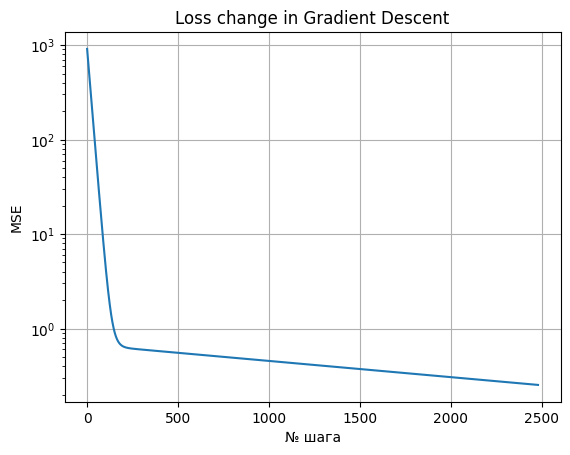

In [61]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title('Loss change in Gradient Descent')
plt.xlabel('№ шага')
plt.ylabel('MSE')
plt.yscale('log')
plt.grid()
plt.show()

In [124]:
from tqdm.notebook import tqdm


loss_history = []
# Повторить до схождения
# while True:
for step in tqdm(range(number_of_steps)):
    
    # 1. Сделать предсказание 
    # y_pred_1 = w_1 * x_11 + w_2 * x_12 + ... + w_0
    # y_pred_2 = w_1 * x_21 + w_2 * x_22 + ... + w_0
    y_prediction = X @ weights

    # 2. Посчитать ошибку MSE
    error = np.mean((y_prediction - y_true) ** 2)
    
    if step % 200 == 0: 
        print(f'Шаг {step} - MSE {round(error, 2)}')

    # 3. Посчитать производные для каждого веса
    gradient = 2 * X.T @ (y_prediction - y_true) / number_of_objects

    # 4. Сделать шаг градиентного спуска
    new_weights = weights - learning_rate * gradient 

    # 5. Проверить на критерий остановки
    if np.linalg.norm(weights - new_weights) < stop_criterion:
        print(f'Шаг {step} - Final MSE {round(error, 2)}')
        break

    weights = new_weights
    loss_history.append(error)

  0%|          | 0/5000 [00:00<?, ?it/s]

/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_23531/2882906916.py:12: RuntimeWarning: divide by zero encountered in matmul
  y_prediction = X @ weights
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_23531/2882906916.py:12: RuntimeWarning: overflow encountered in matmul
  y_prediction = X @ weights
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_23531/2882906916.py:12: RuntimeWarning: invalid value encountered in matmul
  y_prediction = X @ weights


Шаг 0 - MSE 1395.78
Шаг 200 - MSE 2.2
Шаг 400 - MSE 1.99
Шаг 600 - MSE 1.84
Шаг 800 - MSE 1.7
Шаг 1000 - MSE 1.57
Шаг 1200 - MSE 1.45
Шаг 1400 - MSE 1.34
Шаг 1600 - MSE 1.24
Шаг 1800 - MSE 1.15
Шаг 2000 - MSE 1.06
Шаг 2200 - MSE 0.98
Шаг 2400 - MSE 0.91
Шаг 2600 - MSE 0.84
Шаг 2800 - MSE 0.77
Шаг 3000 - MSE 0.72
Шаг 3200 - MSE 0.66
Шаг 3400 - MSE 0.61
Шаг 3600 - MSE 0.56
Шаг 3800 - MSE 0.52
Шаг 4000 - MSE 0.48
Шаг 4200 - MSE 0.45
Шаг 4400 - MSE 0.41
Шаг 4600 - MSE 0.38
Шаг 4800 - MSE 0.35


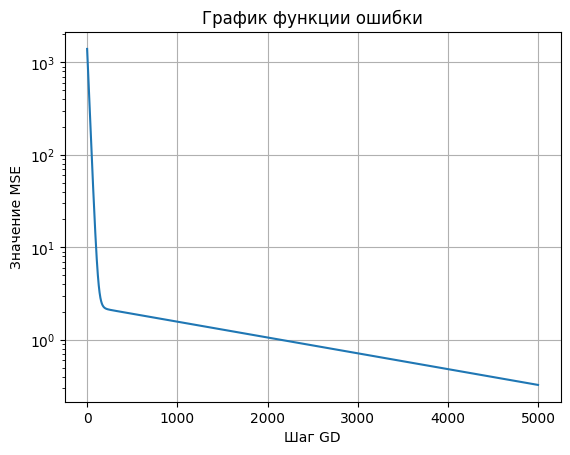

In [125]:
import matplotlib.pyplot as plt

plt.plot(np.arange(0, len(loss_history)), loss_history)
plt.title('График функции ошибки')
plt.xlabel('Шаг GD')
plt.ylabel('Значение MSE')
plt.yscale('log')
plt.grid()
plt.show()

## V. SGD

In [131]:
weights = init_weights.copy()

In [132]:
sgd_loss_history = []
for step in tqdm(range(number_of_steps)):
    selected_object_index = np.random.randint(0, number_of_objects)
    
    y_prediction = X @ weights # можем считать только для выбранного объекта
    error = np.mean((y_prediction - y_true) ** 2) # можем считать ошибку только для выбранного объекта
    
    if step % 200 == 0: 
        print(f'Шаг {step} - MSE {round(error, 2)}')
        
    gradient = 2 * X[selected_object_index].T * (y_prediction[selected_object_index] - y_true[selected_object_index])

    new_weights = weights - learning_rate * gradient 

    if np.linalg.norm(weights - new_weights) < stop_criterion * 10e-2:
        print(f'Шаг {step} - Final MSE {round(error, 2)}')
        break

    weights = new_weights
    sgd_loss_history.append(error)

  0%|          | 0/5000 [00:00<?, ?it/s]

Шаг 0 - MSE 1395.78
Шаг 200 - MSE 2.11
Шаг 400 - MSE 1.99
Шаг 600 - MSE 1.89
Шаг 800 - MSE 1.8
Шаг 1000 - MSE 1.59
Шаг 1200 - MSE 1.48
Шаг 1400 - MSE 1.36
Шаг 1600 - MSE 1.27
Шаг 1800 - MSE 1.16
Шаг 2000 - MSE 1.04
Шаг 2200 - MSE 1.03
Шаг 2400 - MSE 0.92
Шаг 2600 - MSE 0.95
Шаг 2800 - MSE 0.81
Шаг 3000 - MSE 0.77
Шаг 3200 - MSE 0.71
Шаг 3400 - MSE 0.65
Шаг 3600 - MSE 0.56
Шаг 3800 - MSE 0.55
Шаг 4000 - MSE 0.5
Шаг 4200 - MSE 0.44
Шаг 4400 - MSE 0.44
Шаг 4600 - MSE 0.39
Шаг 4800 - MSE 0.37


/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_23531/3168079669.py:5: RuntimeWarning: divide by zero encountered in matmul
  y_prediction = X @ weights # можем считать только для выбранного объекта
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_23531/3168079669.py:5: RuntimeWarning: overflow encountered in matmul
  y_prediction = X @ weights # можем считать только для выбранного объекта
/var/folders/t3/qg2d8hw10yv44bl9j5sr279c0000gn/T/ipykernel_23531/3168079669.py:5: RuntimeWarning: invalid value encountered in matmul
  y_prediction = X @ weights # можем считать только для выбранного объекта


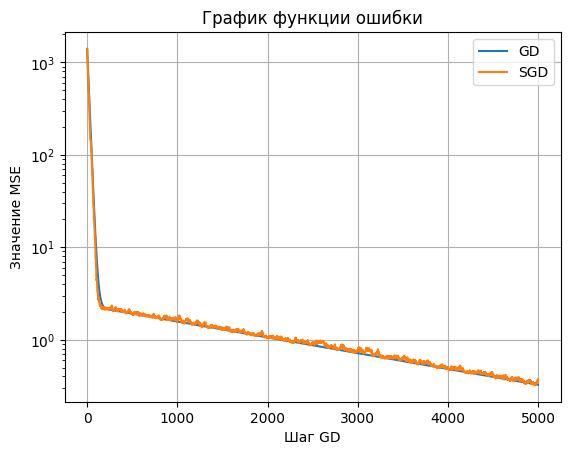

In [133]:
import matplotlib.pyplot as plt

plt.plot(np.arange(0, len(loss_history)), loss_history, label='GD')
plt.plot(np.arange(0, len(sgd_loss_history)), sgd_loss_history, label='SGD')
plt.title('График функции ошибки')
plt.xlabel('Шаг GD')
plt.ylabel('Значение MSE')
plt.yscale('log')
plt.grid()
plt.legend()
plt.show()

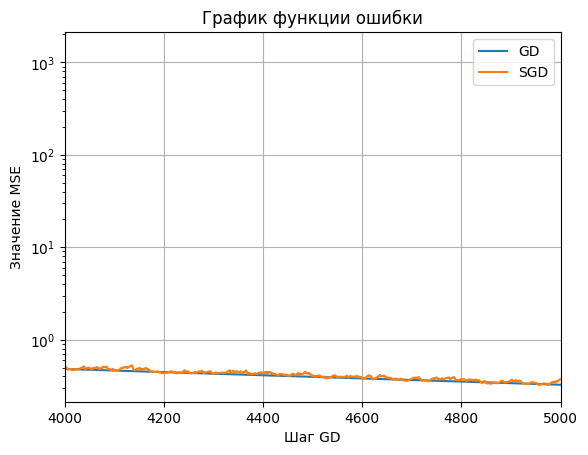

In [135]:
plt.plot(np.arange(0, len(loss_history)), loss_history, label='GD')
plt.plot(np.arange(0, len(sgd_loss_history)), sgd_loss_history, label='SGD')
plt.title('График функции ошибки')
plt.xlabel('Шаг GD')
plt.ylabel('Значение MSE')
plt.yscale('log')
plt.xlim((4000, 5000))
plt.grid()
plt.legend()
plt.show()